In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df=pd.read_csv('Tweets.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [18]:
df=df.dropna()

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
#convert label string to categorical
df['label_id'] = df['sentiment'].factorize()[0]
cat_id = df[['sentiment', 'label_id']].drop_duplicates().sort_values('label_id')
cat_to_id = dict(cat_id.values)
id_to_cat = dict(cat_id[['label_id', 'sentiment']].values)

#show data id_to_kategori
id_to_cat

{0: 'neutral', 1: 'negative', 2: 'positive'}

In [21]:
#checking dataset value
label = df['label_id'].values
text = df['selected_text'].values

print('Value of [label]:', label, "\n")
print('Value of [text]:', text)

Value of [label]: [0 1 1 ... 2 2 0] 

Value of [text]: ['I`d have responded, if I were going' 'Sooo SAD' 'bullying me' ...
 'Yay good for both of you.' 'But it was worth it  ****.'
 'All this flirting going on - The ATG smiles. Yay.  ((hugs)']


In [22]:
#max features
maxfeatures = 10000

#tokenization
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words = maxfeatures)
tokenizer.fit_on_texts(text)

In [23]:
#max sequential per word in NN
maxseqlen = max([len(i.split()) for i in text])
print(maxseqlen)

33


In [24]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

X = tokenizer.texts_to_sequences(text)
X = pad_sequences(X, maxseqlen)
y = to_categorical(label, num_classes = 3)

print("Shape of data tensor ['text']:", X.shape)
print("Shape of data tensor ['label']:", y.shape)

Shape of data tensor ['text']: (27480, 33)
Shape of data tensor ['label']: (27480, 3)


In [25]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

print(Xtrain.shape, ytrain.shape)
print(Xtest.shape, ytest.shape)

(21984, 33) (21984, 3)
(5496, 33) (5496, 3)


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Embedding, Dense, GlobalMaxPool1D, Input
from tensorflow.keras.optimizers import RMSprop

model = Sequential([
    Input(shape=(maxseqlen,)),  # ✅ THIS FIXES EVERYTHING
    Embedding(input_dim=maxfeatures, output_dim=128),
    LSTM(128, return_sequences=True),
    GlobalMaxPool1D(),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(3, activation='softmax')
])

opt = RMSprop(learning_rate=0.0012, rho=0.7, momentum=0.5)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 33, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 33, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,931 (5.42 MB)

 Trainable params: 1,420,931 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

#declare checkpoint variable and early stopping to get best model
early_stop = EarlyStopping(monitor = 'val_accuracy', patience = 3)

In [29]:
from datetime import datetime

#training model
start_time = datetime.now()
history = model.fit(Xtrain, ytrain,
                    batch_size = 100, epochs = 15, shuffle = True,
                    validation_split = 0.1, verbose = 1,
                    callbacks=early_stop)
end_time = datetime.now()
print("Time out: {}".format(end_time - start_time))

Epoch 1/15


2026-03-25 15:11:31.679294: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6536 - loss: 0.7873 - val_accuracy: 0.7858 - val_loss: 0.5407
Epoch 2/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8270 - loss: 0.4717 - val_accuracy: 0.8327 - val_loss: 0.4425
Epoch 3/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8695 - loss: 0.3778 - val_accuracy: 0.8458 - val_loss: 0.4204
Epoch 4/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8890 - loss: 0.3297 - val_accuracy: 0.8440 - val_loss: 0.4186
Epoch 5/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9038 - loss: 0.2917 - val_accuracy: 0.8454 - val_loss: 0.4386
Epoch 6/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9143 - loss: 0.2586 - val_accuracy: 0.8472 - val_loss: 0.4547
Epoch 7/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9247 - loss: 0.2268 - val_accuracy: 0.8377 - val_loss: 0.4497
Epoch 8/15
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9346 - loss: 0.2048 - val_accuracy: 0.844

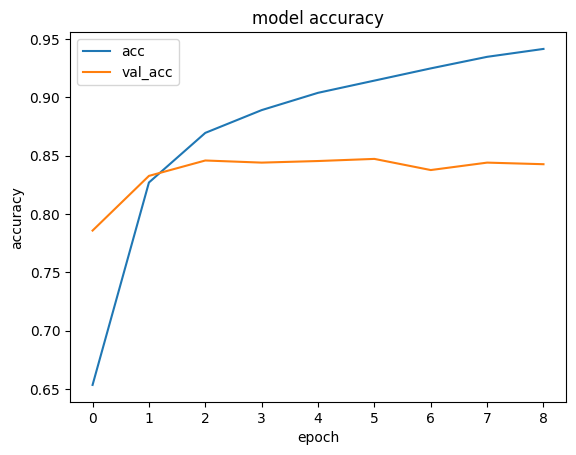

In [30]:
import matplotlib.pyplot as plt

plt.plot (history.history['accuracy'])
plt.plot (history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['acc', 'val_acc'], loc='upper left')
plt.show()